In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
X_train = train_df.drop(columns=['Class'])
y_train = train_df['Class']
X_test = test_df.drop(columns=['Class'])
y_test = test_df['Class']

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
model = xgb.XGBClassifier(
    n_estimators=100, scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr', random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]

In [2]:
def total_cost(y_true, y_proba, threshold, cost_fn=10, cost_fp=1):
    y_pred = (y_proba >= threshold).astype(int)
    fn = ((y_true == 1) & (y_pred == 0)).sum()  # missed fraud
    fp = ((y_true == 0) & (y_pred == 1)).sum()  # false alarm
    return cost_fn * fn + cost_fp * fp, fn, fp

In [3]:
thresholds = np.arange(0.01, 1.0, 0.01)
costs, fns, fps = [], [], []

for t in thresholds:
    cost, fn, fp = total_cost(y_test, y_proba, t)
    costs.append(cost)
    fns.append(fn)
    fps.append(fp)

best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold: {best_threshold:.2f}")
print(f"At this threshold: {fns[best_idx]} missed frauds, {fps[best_idx]} false alarms")
print(f"Total cost: {costs[best_idx]}")

# Compare to naive 0.5 threshold
cost_at_half, fn_half, fp_half = total_cost(y_test, y_proba, 0.5)
print(f"\nAt default 0.5: {fn_half} missed frauds, {fp_half} false alarms, cost={cost_at_half}")

Optimal threshold: 0.31
At this threshold: 15 missed frauds, 15 false alarms
Total cost: 165

At default 0.5: 17 missed frauds, 12 false alarms, cost=182


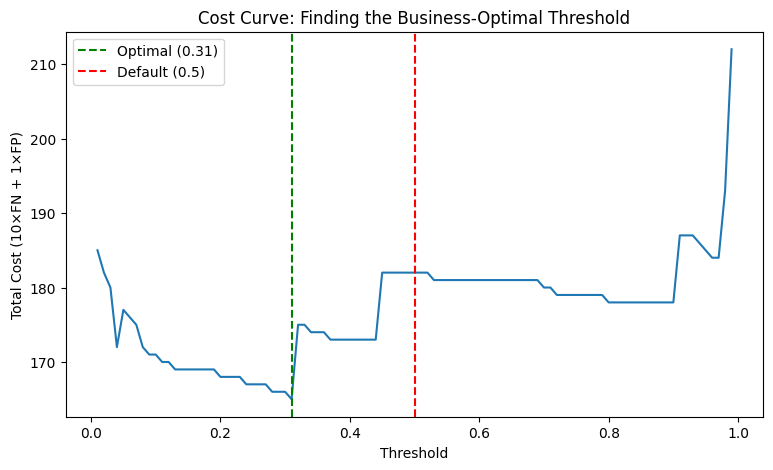

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(thresholds, costs)
plt.axvline(best_threshold, color='green', linestyle='--', label=f'Optimal ({best_threshold:.2f})')
plt.axvline(0.5, color='red', linestyle='--', label='Default (0.5)')
plt.xlabel("Threshold")
plt.ylabel("Total Cost (10×FN + 1×FP)")
plt.title("Cost Curve: Finding the Business-Optimal Threshold")
plt.legend()
plt.savefig("../outputs/04_cost_curve.png", dpi=150, bbox_inches='tight')
plt.show()

In [5]:
for ratio in [2, 5, 10, 20, 50]:
    costs_r = [total_cost(y_test, y_proba, t, cost_fn=ratio, cost_fp=1)[0] for t in thresholds]
    best_t = thresholds[np.argmin(costs_r)]
    print(f"Cost ratio {ratio}:1  ->  optimal threshold = {best_t:.2f}")

Cost ratio 2:1  ->  optimal threshold = 0.96
Cost ratio 5:1  ->  optimal threshold = 0.31
Cost ratio 10:1  ->  optimal threshold = 0.31
Cost ratio 20:1  ->  optimal threshold = 0.01
Cost ratio 50:1  ->  optimal threshold = 0.01
